In [1]:
def pq2tfmatrix(pq):
  import meshcat.transformations as tf
  import numpy as np
  """
  Convert a pq to a transformation matrix
  :param pq: [position, quaternion]
  :return: transformation matrix
  """
  p = pq[:3]
  q = pq[3:]
  q.insert(0, q.pop())
  return tf.quaternion_matrix(q) + np.array([[0, 0, 0, p[0]],
                                             [0, 0, 0, p[1]],
                                             [0, 0, 0, p[2]],
                                             [0, 0, 0, 0]])
    
def robotInit(numLinks, resource_path, displayInitJson, vis):
  import meshcat.geometry as g
  import numpy as np
  robot = vis['robot']
  partInitConfig = displayInitJson['part_init_config']
  for i in range(numLinks):
    robot[str(i)].set_transform(pq2tfmatrix(partInitConfig[i]))

  geometryPool = displayInitJson['geometry_pool']
  for i in range(len(geometryPool)):
    geometry = geometryPool[i]
    meshcatGeo = robot[str(geometry['part_id'])][str(geometry['geometry_id'])]
    meshcatGeo.set_transform(np.array(geometry['init_pm']).reshape(4, 4))
    if i % 2 == 1: 
      material = g.MeshPhongMaterial(color=0x0660FF)
    else:
      material = g.MeshPhongMaterial(color=0xD4D4D4)
    if i == 0:
      material = g.MeshPhongMaterial(color=0x755338)
    if(geometry['shape_type'] == 'box'):
      meshcatGeo.set_object(g.Box([geometry['length'], geometry['width'], geometry['height']]), material=material)
    elif(geometry['shape_type'] == 'capsule'):
      meshcatGeo.set_object(g.Cylinder(geometry['size'][0], geometry['size'][1]), material=material)
    elif(geometry['shape_type'] == 'sphere'):
      meshcatGeo.set_object(g.Sphere(geometry['radius']), material=material)
    elif(geometry['shape_type'] == 'mesh'):
      ext = geometry['resource_path'].split('.')[-1]
      if ext == 'stl':
        meshcatGeo.set_object(g.StlMeshGeometry.from_file(
          resource_path, geometry['resource_path']), material=material)
      elif ext == 'obj':
        meshcatGeo.set_object(g.ObjMeshGeometry.from_file(
          resource_path + geometry['resource_path']), material=material)
      else:
        print("Unknown mesh file type", ext)

def setRobotPq(numLinks, frame, pqs):
  robot = frame['robot']
  for i in range(numLinks):
    robot[str(i)].set_transform(pq2tfmatrix(pqs[i]))

def binarySearch(timeIndices, time):
  import math
  """
  Binary search to find the index of the closest time
  :param timeIndices: list of time indices
  :param time: target time
  :return: index of the closest time index
  """
  low = 0
  high = len(timeIndices) - 1
  while low <= high:
    mid = (low + high) // 2
    if math.isclose(timeIndices[mid], time):
      return mid
    if timeIndices[mid] < time:
      low = mid + 1
    else:
      high = mid - 1

  return min(int(low), len(timeIndices) - 1)

def animateRobotByRecords(numLinks, records, frameRate, vis):
  from meshcat.animation import Animation
  partpq = records['partPq']
  timeIndices = records['timeIndex']
  anim = Animation()
  anim.default_framerate = frameRate

  minTime = 0
  maxTime = timeIndices[-1]
  totalFrameNumber = int((maxTime - minTime) * anim.default_framerate)

  for i in range(totalFrameNumber):
    currentTime = minTime + i / anim.default_framerate
    currentIdx = binarySearch(timeIndices, currentTime)
    with anim.at_frame(vis, i) as frame:
      setRobotPq(numLinks, frame, partpq[currentIdx])

  vis.set_animation(anim)

In [2]:
import sys
sys.path.append("D:/code/sire/install/python/release")
import sire

In [3]:
from os.path import abspath
import os
cs = sire.ControlServer.instance()
print(abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
cs.init()

d:\code\sire\demo\demo_python/sire_ball_free_fall.xml


In [4]:
simulator = sire.simulator(cs)
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  simulator.step(1, False)
  # print("Simulation time", simulator.simTime())

In [5]:
model = cs.model()
displayInitJson = model.displayInitJson()
result = simulator.recordsToJson()

In [6]:
import meshcat
displayInitJson
vis = meshcat.Visualizer()
resourcePath = "D:/code/sire/web_interface/public"
robotInit(model.numLinks(), resourcePath, displayInitJson, vis)
animateRobotByRecords(model.numLinks(), result, 1000, vis)
vis.jupyter_cell()

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7002/static/


In [7]:
for i in range(800):
  currentIdx = 4000 + i
  print(result["timeIndex"][currentIdx])

3.9909999999996715
3.9919999999996714
3.9929999999996713
3.993999999999671
3.994999999999671
3.995999999999671
3.996999999999671
3.9979999999996707
3.9989999999996706
3.9999999999996705
4.000999999999671
4.001999999999671
4.0029999999996715
4.003999999999672
4.004999999999672
4.005225422587168
4.0059999999996725
4.006999999999673
4.007999999999673
4.0089999999996735
4.009999999999674
4.010999999999674
4.0119999999996745
4.012999999999675
4.013999999999675
4.0149999999996755
4.015999999999676
4.016999999999676
4.0179999999996765
4.018999999999677
4.019999999999677
4.020226298085127
4.0209999999996775
4.021999999999678
4.022999999999678
4.0239999999996785
4.024999999999679
4.025999999999679
4.0269999999996795
4.027229636261885
4.02799999999968
4.02899999999968
4.0291294588552535
4.0299999999996805
4.030999999999681
4.031999999999681
4.0329999999996815
4.0332333111522285
4.033999999999682
4.034999999999682
4.035127830009037
4.0359999999996825
4.036999999999683
4.037999999999683
4.03899999

252 0.25000000000000017 0.0009999999999999731 [0.0, 0.0, 1.00002766405641, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -0.09072437029330115, 0.0, 0.0, 0.0] [-0.0, -0.0, -9.8, 0.0, 0.0, -0.0] None
253 0.25100000000000017 0.0010000000000000009 [0.0, 0.0, 0.9999271396861168, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -0.10052437029330116, 0.0, 0.0, 0.0] [0.0, 0.0, 0.1999999999999993, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 554.6422108901105], 'contactWrench': [-0.0, 0.0, 554.6422108901105, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.4999635698430584, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': 0.0, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
254 0.25123958980158295 0.0002395898015827706 [0.0, 0.0, 0.9999343307983699, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 0.030014266907778475, 0.0, 0.0, 0.0] [0.0, 0.0, -9.8, -0.0, -0.0, -0.0] None
255 0.25200000000000017 0.0007604101984172162 [0.0, 0.0, 0.99995148736106, 0.0, 0.0, 0.0, 1.0] 

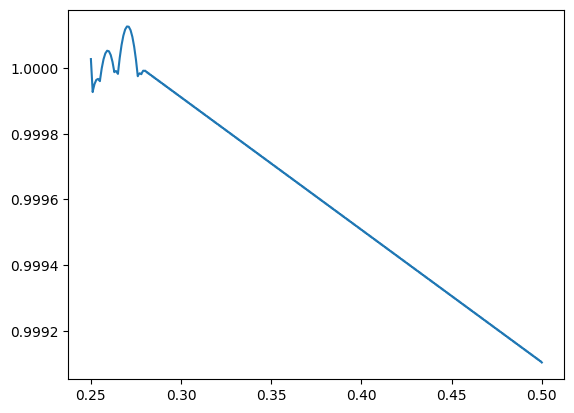

In [6]:
import matplotlib.pyplot as plt
timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
dts = result["dts"]
x = []
y = []

lowerBound = binarySearch(timeIndices, 0.25)
upperBound = binarySearch(timeIndices, 0.5)

for i in range(lowerBound, upperBound + 1):
  print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  x.append(timeIndices[i])
  y.append(pq2tfmatrix(partpq[i][1])[2, 3])  # z position from transformation matrix

plt.plot(x, y)

In [9]:
currentIdx = 4015
print(currentIdx, timeIndices[currentIdx], dts[currentIdx], partpq[currentIdx][1], partvs[currentIdx][1], partas[currentIdx][1], contactInfo[currentIdx])
currentIdx = binarySearch(result["timeIndex"], 4.0052)
print(currentIdx, timeIndices[currentIdx], dts[currentIdx], partpq[currentIdx][1], partvs[currentIdx][1], partas[currentIdx][1], contactInfo[currentIdx])
currentIdx = binarySearch(result["timeIndex"], 4.00525)
print(currentIdx, timeIndices[currentIdx], dts[currentIdx], partpq[currentIdx][1], partvs[currentIdx][1], partas[currentIdx][1], contactInfo[currentIdx])


4015 4.005225422587168 0.00022542258749600242 [0.0, 0.0, 0.9999333600171463, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 0.07830502947316159, 0.0, 0.0, 0.0] [0.0, 0.0, -9.8, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 0.0], 'contactWrench': [-0.0, 0.0, 0.0, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.49996668000857314, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': -1.765172235779211e-05, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
4015 4.005225422587168 0.00022542258749600242 [0.0, 0.0, 0.9999333600171463, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 0.07830502947316159, 0.0, 0.0, 0.0] [0.0, 0.0, -9.8, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 0.0], 'contactWrench': [-0.0, 0.0, 0.0, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.49996668000857314, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': -1.765172235779211e-05, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed

In [10]:
# 4.190999999999734 [0.0, 0.0, 1.0000021810337338, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -0.002929150576415091, 0.0, 0.0, 0.0] [-0.0, -0.0, -9.8, 0.0, 0.0, -0.0] None
# 4.191999999999735 [0.0, 0.0, 0.9999894518831575, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -0.012729150576418364, 0.0, 0.0, 0.0] [0.0, 0.0, 87.49722059997538, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 97.29722059997538], 'contactWrench': [-0.0, 0.0, 97.29722059997538, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.49999472594157873, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': 0.0, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
# 4.192999999999735 [0.0, 0.0, 0.9999914954560379, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 0.00028451290447994385, 0.0, 0.0, 0.0] [0.0, 0.0, -9.8, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 0.0], 'contactWrench': [-0.0, 0.0, 0.0, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.49999574772801897, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': -2.1780204040311446e-07, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
# 4.193999999999735 [0.0, 0.0, 0.9999819799689424, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -0.009515487095523328, 0.0, 0.0, 0.0] [0.0, 0.0, 895.3468337893621, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 905.1468337893621], 'contactWrench': [-0.0, 0.0, 905.1468337893621, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.4999909899844712, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': 9.515487095490549e-06, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
